<a href="https://colab.research.google.com/github/susu-xxx/MyStudy/blob/DeepLearning/ex03_1)_%EA%B0%9C_%EA%B3%A0%EC%96%91%EC%9D%B4_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EC%A0%84%EC%B2%98%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Colab Notebooks/SW엔지니어

/content/drive/MyDrive/Colab Notebooks/SW엔지니어


### 목표
- 강아지 고양이 이미지를 배열로 변환하는 작업을 진행 (이미지 데이터 전처리)
  - 압축된 형식의 배열로 저장 : npz(Numpy 라이브러리에서 읽고 쓸 수 있는 바이너리 파일)
  - 대용량 데이터를 압축 형태로 정리해두면 클라우드환경에 쉽게 업로드, 다운로드 가능(관리가 편함)
  - 저장 공간 적게 차지



In [3]:
# 1. 압축 폴더 해제
# 2. 이미지 한 장씩 접근
# 3. 이미지 크기 조정
# 4. 배열 변환
# 5. 모든 이미지를 npz 형식으로 저장

In [4]:
# 필요한 라이브러리들 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from zipfile import ZipFile

from PIL import Image
import os

In [7]:
zip_file_path = './data/cats_and_dogs_filtered.zip'

with ZipFile(zip_file_path, 'r') as f: #사용할 파일 ('r' 읽기 모드)로 열기
  # path에 있는 압축파일을 해제 후 폴더를 저장할 경로 설정
  f.extractall(path='./data')

  # 결론 = 압축해제

In [8]:
# train -cats, dogs
# test  -cats, dog

In [10]:
# 총 4개의 폴더 경로를 변수에 저장
train_cats_dir = './data/cats_and_dogs_filtered/train/cats'
train_dogs_dir = './data/cats_and_dogs_filtered/train/dogs'

test_cats_dir = './data/cats_and_dogs_filtered/test/cats'
test_dogs_dir = './data/cats_and_dogs_filtered/test/dogs'

# 각 폴더에 있는 이미지의 파일명 접근
#os.listdir

train_cats_fn = os.listdir(train_cats_dir)
train_dogs_fn = os.listdir(train_dogs_dir)

test_cats_fn = os.listdir(test_cats_dir)
test_dogs_fn = os.listdir(test_dogs_dir)

#각각의 이미지 파일 몇 개 들어있는지 개수 확인
print(len(train_cats_fn), len(train_dogs_fn))
print(len(test_cats_fn), len(test_dogs_fn))

1000 1000
500 500


array([[[203, 164,  87],
        [205, 166,  89],
        [209, 170,  93],
        ...,
        [245, 204, 120],
        [242, 202, 122],
        [239, 200, 121]],

       [[203, 164,  87],
        [205, 166,  89],
        [209, 170,  93],
        ...,
        [245, 204, 121],
        [242, 203, 123],
        [240, 201, 122]],

       [[203, 164,  87],
        [205, 166,  89],
        [209, 170,  93],
        ...,
        [245, 205, 122],
        [243, 204, 124],
        [241, 202, 123]],

       ...,

       [[154, 123,  56],
        [155, 124,  57],
        [156, 125,  58],
        ...,
        [  3,   3,   1],
        [  3,   3,   1],
        [  3,   3,   1]],

       [[153, 122,  55],
        [153, 122,  55],
        [154, 123,  56],
        ...,
        [  2,   2,   0],
        [  2,   2,   0],
        [  2,   2,   0]],

       [[151, 120,  53],
        [152, 121,  54],
        [153, 122,  55],
        ...,
        [  1,   1,   0],
        [  1,   1,   0],
        [  1,   1,   0]]], dtype=uint8)
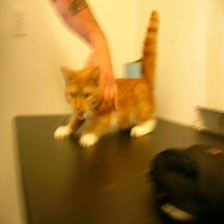

In [18]:
# 이미짖 1장 크기 조정 후 arr 변환
# train_cat 이미지 1장
# train_cats_fn[0]
tmp_path = os.path.join(train_cats_dir, train_cats_fn[0])
# tmp_path = train_cats_dir + '/' + train_cats_fn[0], 위와 동일

img = Image.open(tmp_path).resize((224, 224))
np.array(img)


In [19]:
from tqdm.auto import tqdm

In [21]:
#전처리해주는함수 생성
#사진을 불러와서 배열로 바꾸즌 하수
# 폴더명, 각 파일명 변수, 이미지 사이즈 = 224*224
def prepro_imgs(folder_path, file_names, img_size = (224,224)) :
  imgs = [] # 1장씩 변환해서 append

  #각 이미지 접근해서 불러오기 -> 크기 조정 -> arr -_> 리스트에 담아줌
  for i in tqdm(file_names) : #고양이나 강아지 파일 이름들

    path = os.path.join(folder_path,i)
    #해당 경로 이미지지 불러옴 -> 크기 조정
    img = Image.open(path).resize(img_size)

    #array 변환
    imgs.append(np.array(img))
  return np.array(imgs)

In [23]:
#정의한 함수  사용

#train-cats
x_train_cats = prepro_imgs(train_cats_dir, train_cats_fn)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [24]:
# 나머지 폴더 이미지 변환해보기
x_train_dogs = prepro_imgs(train_dogs_dir, train_dogs_fn)
x_test_cats = prepro_imgs(test_cats_dir, test_cats_fn)
x_test_dogs = prepro_imgs(test_dogs_dir, test_dogs_fn)

#크기 확인
print('훈련셋 : ', x_train_cats.shape, x_train_dogs.shape)
print('테스트셋 : ', x_test_cats.shape, x_test_dogs.shape)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

훈련셋 :  (1000, 224, 224, 3) (1000, 224, 224, 3)
테스트셋 :  (500, 224, 224, 3) (500, 224, 224, 3)


In [26]:
# 두 개의 배열을 병합하는 함수
a = np.array([[1,2], [3,4]])
b = np.array([[5,6], [7,8]])

np.concatenate((a,b), axis=0)

array([[1, 2],
       [3, 4],
       [5, 6],
       [7, 8]])

In [27]:
# train cats, dogs 병합
x_train = np.concatenate((x_train_cats, x_train_dogs), axis=0)
x_test = np.concatenate((x_test_cats, x_test_dogs), axis=0)

# 크기 확인
print(x_train.shape, x_test.shape)

(2000, 224, 224, 3) (1000, 224, 224, 3)


In [28]:
# 정답 데이터 생성
#numpy 1차원 배열로 생성
#cat 0, dog 1

y_train = np.array([0]*1000 + [1]*1000)
y_test = np.array([0]*500 + [1]*500)

print(y_train.shape, y_test.shape)

(2000,) (1000,)


In [29]:
# 데이터 세팅 완료 -> npz
# 여러 개의 파일을 압축하여 하나의 .npz파일로 저장하는 함수
np.savez('./data/cats_and_dogs.npz',
          x_train=x_train,
         x_test=x_test,
         y_train=y_train,
         y_test=y_test)